In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("kirana_sales_500_rows.csv")

In [3]:
df.head()


,Product,Category,Quantity,Price,Date,Total
0,Coffee,Beverage,7,150,2026-04-02,1050
1,Tea,Beverage,4,20,2026-03-21,80
2,Biscuits,Snacks,7,25,2026-06-13,175
3,Sugar,Grocery,10,40,2026-06-12,400
4,Milk,Dairy,7,30,2026-04-01,210


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)

Shape: (500, 6)

Columns:
Index(['Product', 'Category', 'Quantity', 'Price', 'Date', 'Total'], dtype='object')

Data Types:
Product     object
Category    object
Quantity     int64
Price        int64
Date        object
Total        int64
dtype: object


In [5]:
# Duplicate rows check
df.duplicated().sum()

np.int64(7)

In [6]:
df.describe()

,Quantity,Price,Total
count,500.000000,500.000000,500.000000
mean,5.348000,68.030000,366.200000
std,2.814736,57.121755,401.768211
min,1.000000,20.000000,20.000000
25%,3.000000,25.000000,120.000000
50%,5.000000,35.000000,200.000000
75%,8.000000,120.000000,370.000000
max,10.000000,180.000000,1800.000000


In [7]:
df = df.dropna()

In [8]:
df = df.drop_duplicates()


In [9]:
print("Shape after cleaning:", df.shape)
print("Missing Values:")
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

Shape after cleaning: (493, 6)
Missing Values:
Product     0
Category    0
Quantity    0
Price       0
Date        0
Total       0
dtype: int64
Duplicate Rows: 0


In [10]:
top_products = df.groupby("Product")["Total"].sum().sort_values(ascending=False)

print(top_products.head())

Product
Shampoo    48960
Coffee     45750
Oil        27240
Rice       11200
Sugar      10400
Name: Total, dtype: int64


In [11]:
top_products = df.groupby("Product")["Total"].sum().sort_values(ascending=False)

print(top_products.head())

Product
Shampoo    48960
Coffee     45750
Oil        27240
Rice       11200
Sugar      10400
Name: Total, dtype: int64


In [12]:
category_sales = df.groupby("Category")["Total"].sum()

print(category_sales)

Category
Beverage         50290
Dairy             8100
Grocery          56465
Personal Care    59075
Snacks            6525
Name: Total, dtype: int64


In [13]:
daily_sales = df.groupby("Date")["Total"].sum()

print(daily_sales)

Date
2026-01-01    1095
2026-01-02    1250
2026-01-03    1830
2026-01-04     995
2026-01-06     705
              ... 
2026-06-26     425
2026-06-27     220
2026-06-28    2535
2026-06-29     120
2026-06-30    1350
Name: Total, Length: 168, dtype: int64


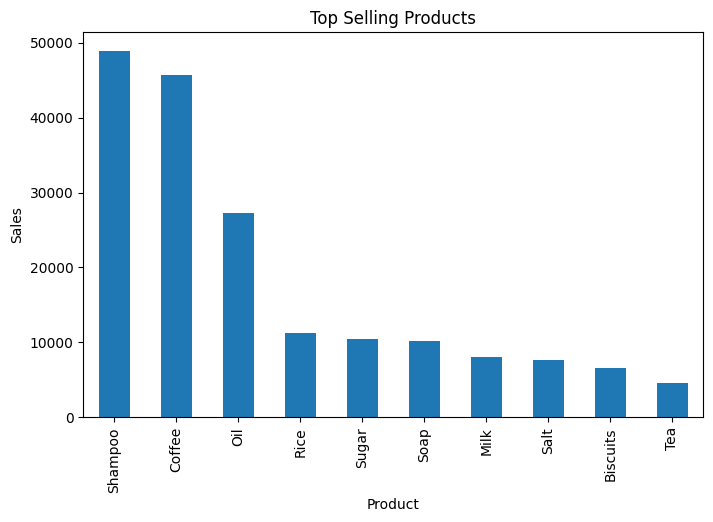

In [14]:
top_products.plot(kind="bar", figsize=(8,5), title="Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

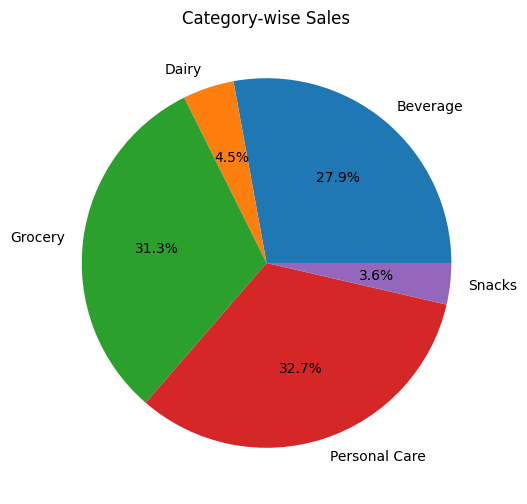

In [15]:
category_sales.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Category-wise Sales")
plt.ylabel("")
plt.show()

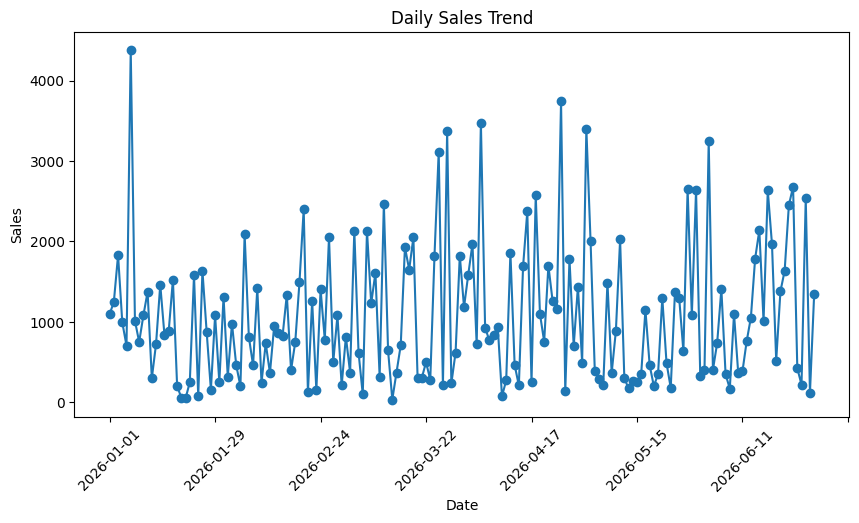

In [16]:
daily_sales.plot(kind="line", figsize=(10,5), marker="o")
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

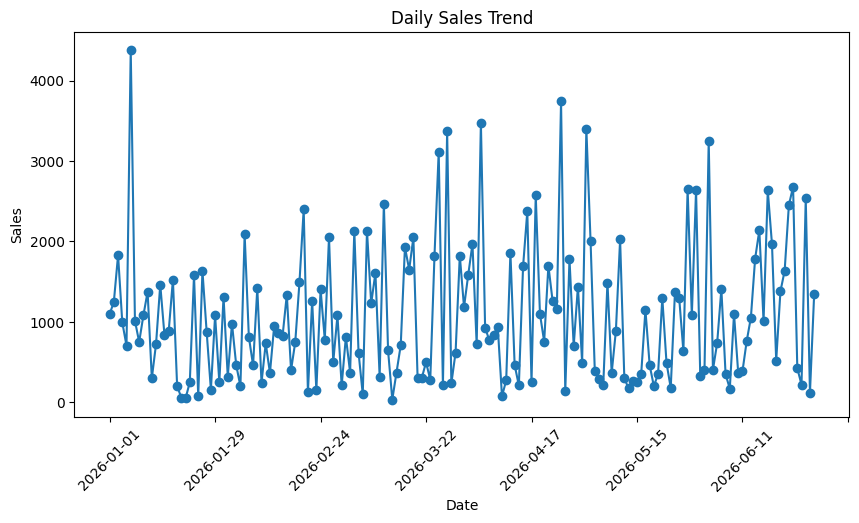

In [17]:
daily_sales.plot(kind="line", figsize=(10,5), marker="o")
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [18]:
print("="*40)
print("      KIRANA STORE DASHBOARD")
print("="*40)

print("Total Sales        :", df["Total"].sum())
print("Total Products Sold:", df["Quantity"].sum())
print("Unique Products    :", df["Product"].nunique())
print("Categories         :", df["Category"].nunique())

      KIRANA STORE DASHBOARD
Total Sales        : 180455
Total Products Sold: 2640
Unique Products    : 10
Categories         : 5


In [19]:
best_product = df.groupby("Product")["Total"].sum().idxmax()
best_sales = df.groupby("Product")["Total"].sum().max()

print("Best Selling Product :", best_product)
print("Sales :", best_sales)

Best Selling Product : Shampoo
Sales : 48960


In [20]:
best_category = df.groupby("Category")["Total"].sum().idxmax()
best_category_sales = df.groupby("Category")["Total"].sum().max()

print("Best Category :", best_category)
print("Sales :", best_category_sales)

Best Category : Personal Care
Sales : 59075


In [21]:
df.to_csv("clean_kirana_sales.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!
